# Pipeline de ML, Otimização e Decisão de Manutenção — Complexo Petroquímico

**Dataset:** `petrochemical_advanced_data.csv`  
**Integrantes:**  
- Elton Vinicios Almeida de Oliveira — RM 562187  
- Emerson dos Santos Silva — RM 562033  
- Kelvin Douglas Ribeiro Rabelo — RM 561538  
- Pedro Henrique Simão Soares — RM 562283  
- Vitor Lucas Mattos de Brito Mariano — RM 562116  
**Execução:** Python 3.12; dependências declaradas em `pyproject.toml`.

Perguntas centrais:

1. Qual configuração operacional reduz custo/intensidade energética mantendo a produção e as restrições?
2. Devemos realizar manutenção e qual parte dessa decisão pode ser automatizada?

> Limite de interpretação: o dataset não possui eventos de falha, intervenções de manutenção, preços reais nem limites oficiais de engenharia. Portanto, o notebook separa resultados aprendidos dos dados de premissas ilustrativas de negócio.

## 0. Setup, dados e verificações de qualidade

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.optimize import NonlinearConstraint, differential_evolution, linprog

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv("../data/petrochemical_advanced_data.csv", parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

quality = pd.Series({
    "linhas": len(df),
    "colunas": df.shape[1],
    "nulos": int(df.isna().sum().sum()),
    "duplicatas completas": int(df.duplicated().sum()),
    "timestamps duplicados": int(df["Timestamp"].duplicated().sum()),
    "início": df["Timestamp"].min(),
    "fim": df["Timestamp"].max(),
    "intervalo dominante": df["Timestamp"].diff().mode().iloc[0],
}, name="valor")
quality.to_frame()

,valor
linhas,10000
colunas,16
nulos,0
duplicatas completas,0
timestamps duplicados,0
início,2020-01-01 00:00:00
fim,2024-07-24 12:00:00
intervalo dominante,0 days 04:00:00


## 1. Entendimento do negócio

O objetivo é reduzir `Energy_Intensity` sem entregar menos que a produção de referência. Os ajustes sugeridos devem permanecer na região histórica da unidade. A decisão de parar uma planta continua humana, pois não há rótulos de falha nem evidência causal do efeito de manutenção.

Regras adotadas:

- consumo de energia e targets são resultados da operação e não entram como preditores;
- o caso degradado é escolhido por regra reproduzível no período de teste, sem seleção manual;
- os limites vêm da unidade analisada e a combinação final precisa estar próxima de configurações realmente observadas;
- custo e risco são cenários explícitos, não valores reais da empresa.

In [3]:
variaveis = pd.DataFrame([
    ["Feedstock_Flow_m3h", "Controlável", "Vazão de alimentação; variável de decisão"],
    ["Reactor_Temp_C", "Controlável", "Temperatura do reator; variável de decisão"],
    ["Reactor_Pressure_Bar", "Controlável", "Pressão do reator; variável de decisão"],
    ["Valve_Opening_Percent", "Controlável", "Abertura de válvula; variável de decisão"],
    ["Sensor_Health_Index", "Estado", "Indicador de condição; não prova falha"],
    ["Vibration_Level_mm_s", "Estado", "Vibração; indicador de condição"],
    ["Catalyst_Age_Days", "Estado", "Idade do catalisador"],
    ["Catalyst_Type", "Estado categórico", "Tipo de catalisador"],
    ["Unit_Name", "Estado categórico", "Unidade produtiva"],
    ["Ambient_Temp_C", "Externa", "Temperatura ambiente"],
    ["Timestamp", "Externa", "Hora e mês em codificação cíclica"],
    ["Electricity_MWh", "Resultado pós-operação", "Entra exatamente no cálculo de Energy_Intensity"],
    ["Natural_Gas_m3h", "Resultado pós-operação", "Entra exatamente no cálculo de Energy_Intensity"],
    ["Steam_Tons_h", "Resultado pós-operação", "Não entra na identidade do target; indisponível antes da operação"],
    ["Product_Yield_Tons", "Target", "Produção por intervalo de 4 horas"],
    ["Energy_Intensity", "Target", "Intensidade energética por tonelada"],
], columns=["Variável", "Classificação", "Papel no problema"])
variaveis

,Variável,Classificação,Papel no problema
0,Feedstock_Flow_m3h,Controlável,Vazão de alimentação; variável de decisão
1,Reactor_Temp_C,Controlável,Temperatura do reator; variável de decisão
2,Reactor_Pressure_Bar,Controlável,Pressão do reator; variável de decisão
3,Valve_Opening_Percent,Controlável,Abertura de válvula; variável de decisão
4,Sensor_Health_Index,Estado,Indicador de condição; não prova falha
5,Vibration_Level_mm_s,Estado,Vibração; indicador de condição
6,Catalyst_Age_Days,Estado,Idade do catalisador
7,Catalyst_Type,Estado categórico,Tipo de catalisador
8,Unit_Name,Estado categórico,Unidade produtiva
9,Ambient_Temp_C,Externa,Temperatura ambiente


## 2. EDA e Feature Engineering

Product_Yield_Tons                                  Energy_Intensity                            
                                 count    mean     std     min      max            count   mean    std    min    max
Unit_Name                                                                                                           
Ammonia_Unit_02                   3347  80.262  14.162  40.621  130.334             3347  2.886  0.637  1.509  6.246
Ethylene_Plant_01                 3354  80.382  14.103  45.109  128.616             3354  2.882  0.618  1.453  5.585
Methanol_Complex_03               3299  80.005  13.978  42.203  133.977             3299  2.887  0.620  1.331  6.387

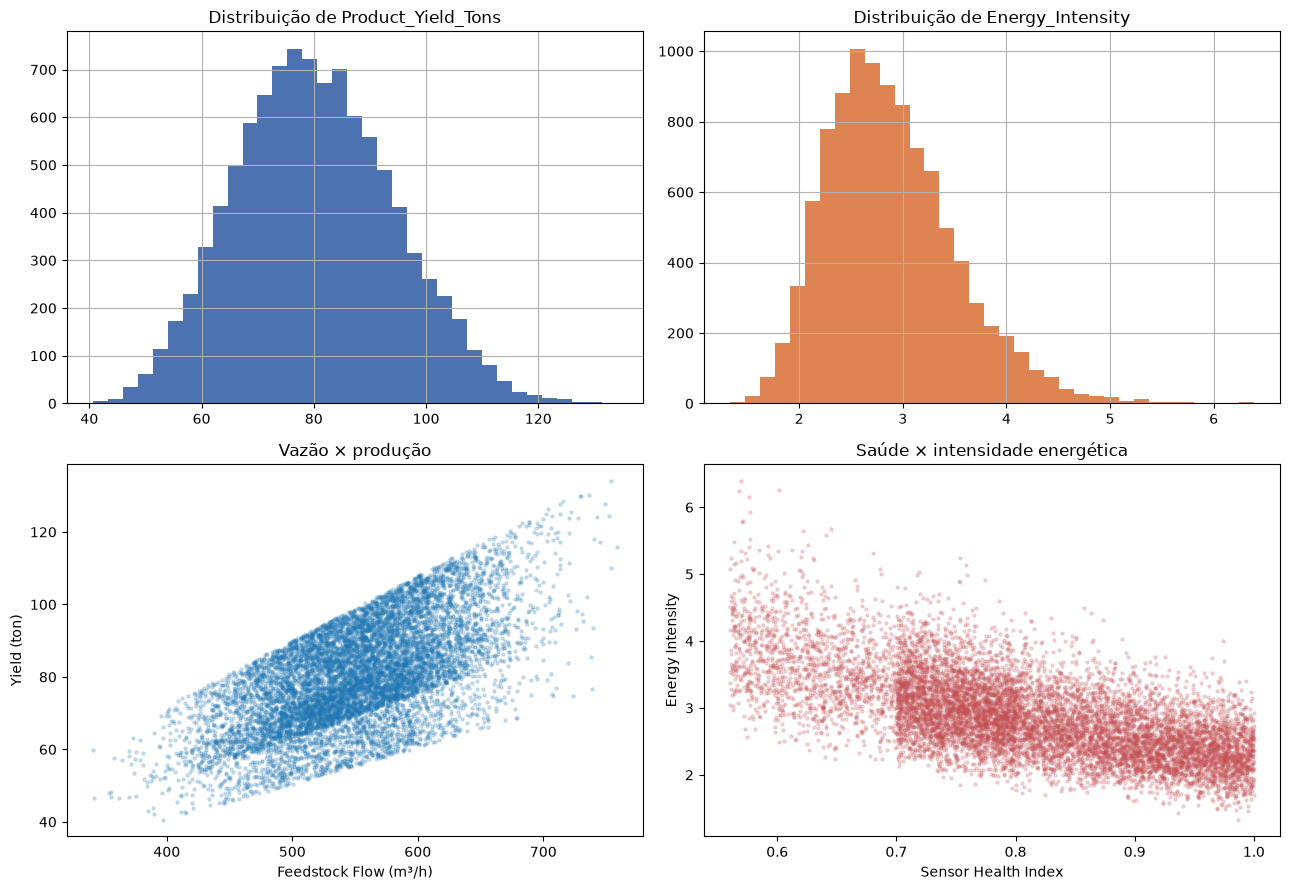

In [4]:
targets_by_unit = df.groupby("Unit_Name")[["Product_Yield_Tons", "Energy_Intensity"]].agg(["count", "mean", "std", "min", "max"])
display(targets_by_unit.round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
df["Product_Yield_Tons"].hist(bins=35, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribuição de Product_Yield_Tons")
df["Energy_Intensity"].hist(bins=35, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Distribuição de Energy_Intensity")
axes[1, 0].scatter(df["Feedstock_Flow_m3h"], df["Product_Yield_Tons"], s=5, alpha=.2)
axes[1, 0].set(xlabel="Feedstock Flow (m³/h)", ylabel="Yield (ton)", title="Vazão × produção")
axes[1, 1].scatter(df["Sensor_Health_Index"], df["Energy_Intensity"], s=5, alpha=.2, color="#C44E52")
axes[1, 1].set(xlabel="Sensor Health Index", ylabel="Energy Intensity", title="Saúde × intensidade energética")
plt.tight_layout()
plt.show()

In [5]:
# Codificação cíclica evita tratar 23h e 0h, ou dezembro e janeiro, como pontos distantes.
df["hour_sin"] = np.sin(2 * np.pi * df["Timestamp"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["Timestamp"].dt.hour / 24)
df["month_sin"] = np.sin(2 * np.pi * (df["Timestamp"].dt.month - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["Timestamp"].dt.month - 1) / 12)

# Interação entre duas informações disponíveis antes da operação.
df["Flow_Health_Interaction"] = df["Feedstock_Flow_m3h"] * df["Sensor_Health_Index"]
df["Equivalent_Energy"] = 3.6 * df["Electricity_MWh"] + 0.035 * df["Natural_Gas_m3h"]

safe_num_features = [
    "Catalyst_Age_Days", "Sensor_Health_Index", "Vibration_Level_mm_s",
    "Valve_Opening_Percent", "Feedstock_Flow_m3h", "Reactor_Temp_C",
    "Reactor_Pressure_Bar", "Ambient_Temp_C",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "Flow_Health_Interaction",
]
cat_features = ["Unit_Name", "Catalyst_Type"]
decision_vars = ["Valve_Opening_Percent", "Feedstock_Flow_m3h", "Reactor_Temp_C", "Reactor_Pressure_Bar"]
X = df[safe_num_features + cat_features]

### 2.1 Target leakage: identidade exata encontrada

Uma verificação algébrica mostra que o target é calculado exatamente por
`Energy_Intensity = (3,6 × Electricity_MWh + 0,035 × Natural_Gas_m3h) / Product_Yield_Tons`.

Logo, eletricidade, gás e produção causariam vazamento direto. `Steam_Tons_h` não participa da identidade, corrigindo a interpretação anterior, mas também é uma medição posterior e não está disponível quando os setpoints são decididos.

Uma segunda auditoria verifica `Product_Yield_Tons = 0,18 × Feedstock_Flow_m3h × Sensor_Health_Index`. A interação usa apenas informações pré-operação: não é leakage, mas evidencia a estrutura sintética da base e permite um modelo híbrido interpretável.

In [6]:
energy_reconstructed = (
    3.6 * df["Electricity_MWh"] + 0.035 * df["Natural_Gas_m3h"]
) / df["Product_Yield_Tons"]
identity_error = np.abs(energy_reconstructed - df["Energy_Intensity"])
yield_reconstructed = 0.18 * df["Flow_Health_Interaction"]
yield_identity_error = np.abs(yield_reconstructed - df["Product_Yield_Tons"])

pd.Series({
    "erro máximo da identidade": identity_error.max(),
    "erro médio da identidade": identity_error.mean(),
    "erro máximo da identidade de produção": yield_identity_error.max(),
    "correlação Steam_Tons_h × target": df["Steam_Tons_h"].corr(df["Energy_Intensity"]),
}).to_frame("valor")

,valor
erro máximo da identidade,1.776357e-15
erro médio da identidade,8.391066e-17
erro máximo da identidade de produção,4.263256e-14
correlação Steam_Tons_h × target,8.326363e-03


### 2.2 Validação temporal, calibração e teste intocado

Os primeiros 80% formam a janela de desenvolvimento e os 20% finais permanecem como teste final. Dentro do desenvolvimento, os primeiros 70% da base ajustam o modelo operacional e os 10% seguintes calibram a incerteza. A estabilidade dos modelos é avaliada por três folds walk-forward expansivos, sem usar o teste final para escolha ou calibração.

In [7]:
split_idx = int(len(df) * 0.8)
calibration_idx = int(len(df) * 0.7)
idx_model_train = df.index[:calibration_idx]
idx_calibration = df.index[calibration_idx:split_idx]
idx_train = df.index[:split_idx]
idx_test = df.index[split_idx:]

print(f"Ajuste operacional: {df.loc[idx_model_train, 'Timestamp'].min()} → {df.loc[idx_model_train, 'Timestamp'].max()} ({len(idx_model_train)} registros)")
print(f"Calibração:         {df.loc[idx_calibration, 'Timestamp'].min()} → {df.loc[idx_calibration, 'Timestamp'].max()} ({len(idx_calibration)} registros)")
print(f"Teste final:        {df.loc[idx_test, 'Timestamp'].min()} → {df.loc[idx_test, 'Timestamp'].max()} ({len(idx_test)} registros)")

def build_pipeline(model):
    prep = ColumnTransformer([
        ("num", "passthrough", safe_num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])
    return Pipeline([("prep", prep), ("model", model)])

model_specs = {
    "LinearRegression": lambda: LinearRegression(),
    "RandomForest": lambda: RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "GradientBoosting": lambda: GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results, fitted = [], {}
for target in ["Energy_Intensity", "Product_Yield_Tons"]:
    for model_name, factory in model_specs.items():
        pipeline = build_pipeline(factory())
        pipeline.fit(X.loc[idx_train], df.loc[idx_train, target])
        pred = pipeline.predict(X.loc[idx_test])
        results.append({
            "Target": target,
            "Modelo": model_name,
            "R2": r2_score(df.loc[idx_test, target], pred),
            "MAE": mean_absolute_error(df.loc[idx_test, target], pred),
            "RMSE": np.sqrt(mean_squared_error(df.loc[idx_test, target], pred)),
        })
        fitted[(target, model_name)] = pipeline

comparison = pd.DataFrame(results)

# Benchmark híbrido: identidade de produção + energia equivalente média do treino.
# Electricity e Natural Gas aparecem apenas na construção do target de treino, nunca como features.
hybrid_yield_test = 0.18 * df.loc[idx_test, "Flow_Health_Interaction"]
equivalent_energy_mean_train = float(df.loc[idx_model_train, "Equivalent_Energy"].mean())
hybrid_energy_test = equivalent_energy_mean_train / hybrid_yield_test
for target, pred in {
    "Energy_Intensity": hybrid_energy_test,
    "Product_Yield_Tons": hybrid_yield_test,
}.items():
    results.append({
        "Target": target,
        "Modelo": "Híbrido físico",
        "R2": r2_score(df.loc[idx_test, target], pred),
        "MAE": mean_absolute_error(df.loc[idx_test, target], pred),
        "RMSE": np.sqrt(mean_squared_error(df.loc[idx_test, target], pred)),
    })
comparison = pd.DataFrame(results)
comparison.round(4)

Ajuste operacional: 2020-01-01 00:00:00 → 2023-03-12 12:00:00 (7000 registros)
Calibração:         2023-03-12 16:00:00 → 2023-08-26 04:00:00 (1000 registros)
Teste final:        2023-08-26 08:00:00 → 2024-07-24 12:00:00 (2000 registros)


,Target,Modelo,R2,MAE,RMSE
0,Energy_Intensity,LinearRegression,0.6801,0.2810,0.3472
1,Energy_Intensity,RandomForest,0.6825,0.2794,0.3459
2,Energy_Intensity,GradientBoosting,0.6888,0.2766,0.3424
3,Product_Yield_Tons,LinearRegression,1.0000,0.0000,0.0000
4,Product_Yield_Tons,RandomForest,0.9999,0.0126,0.1250
5,Product_Yield_Tons,GradientBoosting,0.9999,0.1092,0.1678
6,Energy_Intensity,Híbrido físico,0.6930,0.2761,0.3401
7,Product_Yield_Tons,Híbrido físico,1.0000,0.0000,0.0000


In [8]:
# Walk-forward somente dentro da janela de desenvolvimento; o teste final não participa.
walk_folds = [
    ("Fold 1", df.index[:5000], df.index[5000:6000]),
    ("Fold 2", df.index[:6000], df.index[6000:7000]),
    ("Fold 3", df.index[:7000], df.index[7000:8000]),
]
walk_rows = []
for fold_name, fold_train, fold_valid in walk_folds:
    for target in ["Energy_Intensity", "Product_Yield_Tons"]:
        for model_name, factory in model_specs.items():
            pipeline = build_pipeline(factory()).fit(X.loc[fold_train], df.loc[fold_train, target])
            pred = pipeline.predict(X.loc[fold_valid])
            walk_rows.append({
                "Fold": fold_name, "Target": target, "Modelo": model_name,
                "R2": r2_score(df.loc[fold_valid, target], pred),
                "MAE": mean_absolute_error(df.loc[fold_valid, target], pred),
                "RMSE": np.sqrt(mean_squared_error(df.loc[fold_valid, target], pred)),
            })

        hybrid_yield_valid = 0.18 * df.loc[fold_valid, "Flow_Health_Interaction"]
        hybrid_pred = (
            float(df.loc[fold_train, "Equivalent_Energy"].mean()) / hybrid_yield_valid
            if target == "Energy_Intensity" else hybrid_yield_valid
        )
        walk_rows.append({
            "Fold": fold_name, "Target": target, "Modelo": "Híbrido físico",
            "R2": r2_score(df.loc[fold_valid, target], hybrid_pred),
            "MAE": mean_absolute_error(df.loc[fold_valid, target], hybrid_pred),
            "RMSE": np.sqrt(mean_squared_error(df.loc[fold_valid, target], hybrid_pred)),
        })

walk_forward = pd.DataFrame(walk_rows)
walk_summary = walk_forward.groupby(["Target", "Modelo"])[["R2", "MAE", "RMSE"]].agg(["mean", "std"])
walk_summary.round(4)

R2             MAE            RMSE        
                                       mean     std    mean     std    mean     std
Target             Modelo                                                          
Energy_Intensity   GradientBoosting  0.7161  0.0095  0.2659  0.0043  0.3311  0.0050
                   Híbrido físico    0.7159  0.0093  0.2661  0.0038  0.3312  0.0049
                   LinearRegression  0.6990  0.0136  0.2725  0.0052  0.3409  0.0077
                   RandomForest      0.7115  0.0077  0.2687  0.0031  0.3338  0.0035
Product_Yield_Tons GradientBoosting  0.9999  0.0000  0.1096  0.0044  0.1602  0.0299
                   Híbrido físico    1.0000  0.0000  0.0000  0.0000  0.0000  0.0000
                   LinearRegression  1.0000  0.0000  0.0000  0.0000  0.0000  0.0000
                   RandomForest      0.9999  0.0002  0.0158  0.0066  0.1137  0.1155

In [9]:
# Diagnóstico de generalização por unidade para os modelos escolhidos.
chosen_test_predictions = {
    "Energy_Intensity": hybrid_energy_test,
    "Product_Yield_Tons": hybrid_yield_test,
}
segment_rows = []
for target, pred in chosen_test_predictions.items():
    temp = df.loc[idx_test, ["Unit_Name", target]].copy()
    temp["pred"] = pred
    for unit, group in temp.groupby("Unit_Name"):
        segment_rows.append({
            "Target": target, "Unidade": unit,
            "MAE": mean_absolute_error(group[target], group["pred"]),
            "RMSE": np.sqrt(mean_squared_error(group[target], group["pred"])),
        })
pd.DataFrame(segment_rows).round(4)

,Target,Unidade,MAE,RMSE
0,Energy_Intensity,Ammonia_Unit_02,0.2793,0.3379
1,Energy_Intensity,Ethylene_Plant_01,0.2823,0.3511
2,Energy_Intensity,Methanol_Complex_03,0.2668,0.3314
3,Product_Yield_Tons,Ammonia_Unit_02,0.0000,0.0000
4,Product_Yield_Tons,Ethylene_Plant_01,0.0000,0.0000
5,Product_Yield_Tons,Methanol_Complex_03,0.0000,0.0000


**Escolha:** modelo híbrido para os dois targets. No walk-forward de energia, Gradient Boosting e híbrido ficam tecnicamente empatados (diferença média de RMSE de cerca de 0,0001); no teste final, o híbrido é ligeiramente melhor. Ele foi escolhido pela coerência algébrica e interpretabilidade, não por otimização no teste. Em produção, reproduz a identidade determinística. A incerteza é calibrada sem consultar o teste final e será carregada para a decisão.

,valor
Margem conformal absoluta (90%),5.521042e-01
Margem conformal de produção (90%),1.421085e-14
Cobertura observada no teste final,8.940000e-01
Registros de calibração,1.000000e+03


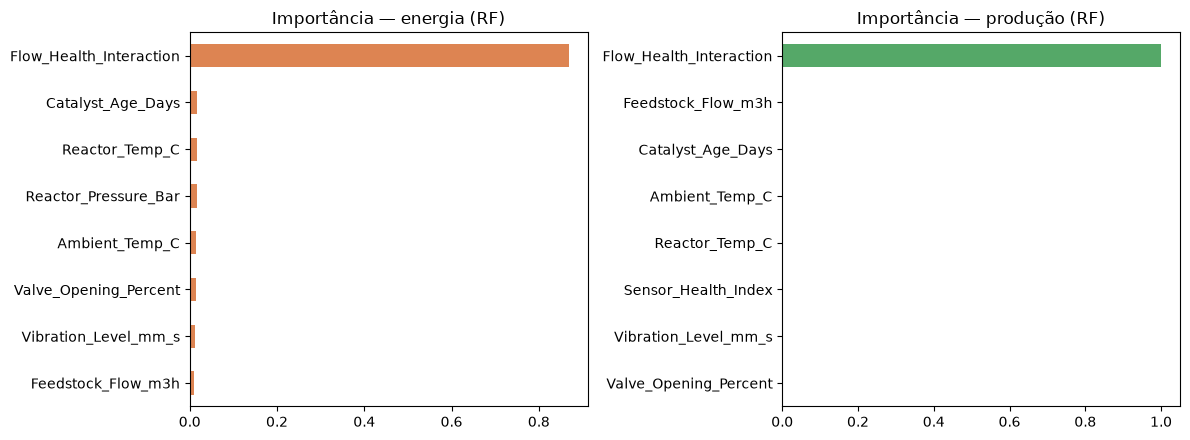

,Energy,Yield
Ambient_Temp_C,0.0149,0.0
Catalyst_Age_Days,0.0163,0.0
Feedstock_Flow_m3h,0.0000,0.0
Flow_Health_Interaction,0.8681,1.0
Reactor_Pressure_Bar,0.0157,0.0
Reactor_Temp_C,0.0157,0.0


In [10]:
# O modelo operacional usa apenas os primeiros 70%; os 10% seguintes calibram
# uma margem conformal. O teste final permanece intocado até a avaliação.
equivalent_energy_mean = float(df.loc[idx_model_train, "Equivalent_Energy"].mean())
calibration_yield = 0.18 * df.loc[idx_calibration, "Flow_Health_Interaction"]
calibration_energy_pred = equivalent_energy_mean / calibration_yield
calibration_abs_residuals = np.abs(
    df.loc[idx_calibration, "Energy_Intensity"].to_numpy() - calibration_energy_pred.to_numpy()
)
conformal_level = min(1.0, np.ceil((len(calibration_abs_residuals) + 1) * 0.90) / len(calibration_abs_residuals))
energy_error_q90 = float(np.quantile(calibration_abs_residuals, conformal_level, method="higher"))
calibration_yield_abs_residuals = np.abs(
    df.loc[idx_calibration, "Product_Yield_Tons"].to_numpy() - calibration_yield.to_numpy()
)
yield_error_q90 = float(np.quantile(calibration_yield_abs_residuals, conformal_level, method="higher"))
test_abs_residuals = np.abs(df.loc[idx_test, "Energy_Intensity"].to_numpy() - np.asarray(hybrid_energy_test))
test_interval_coverage = float(np.mean(test_abs_residuals <= energy_error_q90))

# Surrogates lineares usam somente a janela de desenvolvimento.
lin_energy = build_pipeline(LinearRegression()).fit(X.loc[idx_train], df.loc[idx_train, "Energy_Intensity"])
lin_yield = build_pipeline(LinearRegression()).fit(X.loc[idx_train], df.loc[idx_train, "Product_Yield_Tons"])

display(pd.Series({
    "Margem conformal absoluta (90%)": energy_error_q90,
    "Margem conformal de produção (90%)": yield_error_q90,
    "Cobertura observada no teste final": test_interval_coverage,
    "Registros de calibração": len(idx_calibration),
}).to_frame("valor"))

ohe_cols = list(fitted[("Product_Yield_Tons", "RandomForest")].named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features))
all_cols = safe_num_features + ohe_cols
imp_energy = pd.Series(
    fitted[("Energy_Intensity", "RandomForest")].named_steps["model"].feature_importances_,
    index=all_cols,
).sort_values(ascending=False)
imp_yield = pd.Series(
    fitted[("Product_Yield_Tons", "RandomForest")].named_steps["model"].feature_importances_,
    index=all_cols,
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
imp_energy.head(8).sort_values().plot.barh(ax=axes[0], color="#DD8452", title="Importância — energia (RF)")
imp_yield.head(8).sort_values().plot.barh(ax=axes[1], color="#55A868", title="Importância — produção (RF)")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"Energy": imp_energy.head(5), "Yield": imp_yield.head(5)}).fillna(0).round(4))

Importância de árvore é associativa, não causal. Ela mostra que saúde do sensor e vazão explicam grande parte das previsões, mas não prova que uma intervenção de manutenção causará o ganho previsto.

## 3. Otimização

Para cada estado do equipamento, resolvemos:

\[
\min_x \; \widehat{EI}(x\mid estado) + 10^{-4}D(x,x_{atual})
\]

sujeito a `Yield_hat ≥ produção observada atual`, limites p1–p99 da mesma unidade e distância conjunta até uma configuração histórica menor que o percentil 99. O termo muito pequeno de movimento apenas desempata platôs do modelo em favor de ajustes menores.

`differential_evolution` é usado porque a razão de energia e a restrição de vizinhança tornam o problema não linear. Um `linprog` com surrogates lineares aparece depois como comparação, não como modelo principal.

In [11]:
# Caso selecionado de modo reproduzível: maior escore de degradação no período de teste.
risk_ranks = df[["Sensor_Health_Index", "Vibration_Level_mm_s", "Catalyst_Age_Days"]].rank(pct=True)
df["Degradation_Score"] = (
    0.50 * (1 - risk_ranks["Sensor_Health_Index"])
    + 0.35 * risk_ranks["Vibration_Level_mm_s"]
    + 0.15 * risk_ranks["Catalyst_Age_Days"]
)
current_idx = df.loc[idx_test, "Degradation_Score"].idxmax()
current = df.loc[current_idx]

case_cols = [
    "Timestamp", "Unit_Name", "Catalyst_Type", "Catalyst_Age_Days",
    "Sensor_Health_Index", "Vibration_Level_mm_s", "Feedstock_Flow_m3h",
    "Reactor_Temp_C", "Reactor_Pressure_Bar", "Valve_Opening_Percent",
    "Product_Yield_Tons", "Energy_Intensity", "Degradation_Score",
]
current[case_cols].to_frame("caso degradado")

,caso degradado
Timestamp,2024-05-12 00:00:00
Unit_Name,Ammonia_Unit_02
Catalyst_Type,Cobalt_Premium_Z2
Catalyst_Age_Days,348
Sensor_Health_Index,0.577906
Vibration_Level_mm_s,8.125815
Feedstock_Flow_m3h,618.79311
Reactor_Temp_C,793.624338
Reactor_Pressure_Bar,33.082487
Valve_Opening_Percent,79.844399


In [12]:
state_cols = [
    "Catalyst_Age_Days", "Sensor_Health_Index", "Vibration_Level_mm_s", "Ambient_Temp_C",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "Unit_Name", "Catalyst_Type",
]
state_now = {k: current[k] for k in state_cols}
x_now = current[decision_vars].to_numpy(dtype=float)
yield_min = float(current["Product_Yield_Tons"])

# Referência pós-manutenção: uma linha real e representativa do treino, da mesma unidade e catalisador.
train_df = df.loc[idx_train]
same_asset = train_df[
    (train_df["Unit_Name"] == current["Unit_Name"])
    & (train_df["Catalyst_Type"] == current["Catalyst_Type"])
].copy()
healthy_cohort = same_asset[
    (same_asset["Sensor_Health_Index"] >= same_asset["Sensor_Health_Index"].quantile(.75))
    & (same_asset["Vibration_Level_mm_s"] <= same_asset["Vibration_Level_mm_s"].quantile(.25))
    & (same_asset["Catalyst_Age_Days"] <= same_asset["Catalyst_Age_Days"].quantile(.25))
].copy()
risk_features = ["Sensor_Health_Index", "Vibration_Level_mm_s", "Catalyst_Age_Days"]
cohort_median = healthy_cohort[risk_features].median()
cohort_scale = healthy_cohort[risk_features].std()
healthy_cohort["distance_to_cohort_center"] = (((healthy_cohort[risk_features] - cohort_median) / cohort_scale) ** 2).sum(axis=1)
reference = healthy_cohort.loc[healthy_cohort["distance_to_cohort_center"].idxmin()]

state_restored = dict(state_now)
for feature in risk_features:
    state_restored[feature] = reference[feature]

pd.DataFrame({
    "Atual": current[risk_features],
    "Referência saudável observada": reference[risk_features],
}).round(4)

,Atual,Referência saudável observada
Sensor_Health_Index,0.577906,0.970453
Vibration_Level_mm_s,8.125815,1.749238
Catalyst_Age_Days,348,58


In [13]:
# Limites calculados na unidade; suporte condicionado ao mesmo ativo/unidade e
# ao estado do equipamento, para não comparar setpoints de estados incompatíveis.
unit_history = train_df[train_df["Unit_Name"] == current["Unit_Name"]]
bounds_pct = {v: (unit_history[v].quantile(.01), unit_history[v].quantile(.99)) for v in decision_vars}

support_features = decision_vars + risk_features
support_history = same_asset
support_scaler = StandardScaler().fit(support_history[support_features].to_numpy())
support_points = support_scaler.transform(support_history[support_features].to_numpy())
support_nn = NearestNeighbors(n_neighbors=2).fit(support_points)
train_neighbor_distances = support_nn.kneighbors(support_points)[0][:, 1]
support_limit = float(np.quantile(train_neighbor_distances, .99))

def make_row(x, state):
    row = {**state, **dict(zip(decision_vars, x))}
    row["Flow_Health_Interaction"] = row["Feedstock_Flow_m3h"] * row["Sensor_Health_Index"]
    return pd.DataFrame([row])[safe_num_features + cat_features]

def predict_energy(x, state):
    return equivalent_energy_mean / predict_yield(x, state)

def predict_yield(x, state):
    row = make_row(x, state)
    return float(0.18 * row["Flow_Health_Interaction"].iloc[0])

def predict_energy_upper(x, state):
    return predict_energy(x, state) + energy_error_q90

def predict_yield_lower(x, state):
    return max(0.0, predict_yield(x, state) - yield_error_q90)

def support_distance(x, state):
    support_vector = list(np.asarray(x, dtype=float)) + [float(state[f]) for f in risk_features]
    z = support_scaler.transform(np.asarray(support_vector).reshape(1, -1))[0]
    return float(np.sqrt(((support_points - z) ** 2).sum(axis=1)).min())

display(pd.DataFrame(bounds_pct, index=["p1", "p99"]).T.round(3))
print(f"Limite conjunto de suporte (p99 da distância ao vizinho): {support_limit:.3f}")
print(f"Distância do ponto atual ao histórico condicionado: {support_distance(x_now, state_now):.3f}")

,p1,p99
Valve_Opening_Percent,20.851,94.356
Feedstock_Flow_m3h,412.069,694.106
Reactor_Temp_C,719.434,917.347
Reactor_Pressure_Bar,25.352,38.721


Limite conjunto de suporte (p99 da distância ao vizinho): 2.032
Distância do ponto atual ao histórico condicionado: 0.984


In [14]:
def optimize_state(state, label, robust=False):
    scale = np.array([bounds_pct[v][1] - bounds_pct[v][0] for v in decision_vars])
    def objective(x):
        movement = np.mean(((x - x_now) / scale) ** 2)
        energy_objective = predict_energy_upper(x, state) if robust else predict_energy(x, state)
        return energy_objective + 1e-4 * movement

    constraints = (
        NonlinearConstraint(
            lambda x: predict_yield_lower(x, state) if robust else predict_yield(x, state),
            yield_min, np.inf,
        ),
        NonlinearConstraint(lambda x: support_distance(x, state), -np.inf, support_limit),
    )
    result = differential_evolution(
        objective,
        bounds=[bounds_pct[v] for v in decision_vars],
        constraints=constraints,
        seed=RANDOM_STATE,
        maxiter=120,
        popsize=15,
        tol=1e-7,
        polish=False,
    )
    constrained_yield = predict_yield_lower(result.x, state) if robust else predict_yield(result.x, state)
    feasible = constrained_yield >= yield_min and support_distance(result.x, state) <= support_limit
    if not feasible:
        raise RuntimeError(f"Otimização sem solução viável em {label}: {result.message}")
    x_opt = dict(zip(decision_vars, result.x))
    return {
        "label": label, "x": x_opt,
        "energy": predict_energy(result.x, state),
        "energy_upper": predict_energy_upper(result.x, state),
        "yield": predict_yield(result.x, state),
        "yield_lower": predict_yield_lower(result.x, state),
        "support": support_distance(result.x, state),
        "robust": robust,
        "result": result,
    }

opt_no_maintenance = optimize_state(state_now, "Sem manutenção")
opt_maintenance = optimize_state(state_restored, "Manutenção imediata")
# As margens são globais e aditivas; logo, a formulação robusta preserva
# exatamente o argmin nominal. Reutilizar os setpoints evita variação numérica
# arbitrária em dimensões com efeito preditivo nulo.
robust_no_maintenance = {**opt_no_maintenance, "label": "Sem manutenção robusta", "robust": True}
robust_maintenance = {**opt_maintenance, "label": "Manutenção imediata robusta", "robust": True}

optimization_table = pd.DataFrame({
    "Sem manutenção": {**opt_no_maintenance["x"], "Energy_Intensity": opt_no_maintenance["energy"], "Product_Yield_Tons": opt_no_maintenance["yield"], "Support_Distance": opt_no_maintenance["support"]},
    "Manutenção imediata": {**opt_maintenance["x"], "Energy_Intensity": opt_maintenance["energy"], "Product_Yield_Tons": opt_maintenance["yield"], "Support_Distance": opt_maintenance["support"]},
})
optimization_table.round(4)

,Sem manutenção,Manutenção imediata
Valve_Opening_Percent,79.9122,79.5349
Feedstock_Flow_m3h,694.1058,694.1058
Reactor_Temp_C,789.0296,795.1363
Reactor_Pressure_Bar,33.3611,33.3225
Energy_Intensity,3.1047,1.8488
Product_Yield_Tons,72.2031,121.2475
Support_Distance,2.0315,1.0351


### 3.1 Solução nominal versus robusta

A solução robusta minimiza o limite superior conformal de intensidade e exige que o limite inferior de produção satisfaça a meta. Como a identidade de produção tem erro numérico praticamente zero e a margem energética é aditiva e global, a proteção pode ampliar o valor reportado sem alterar os setpoints. Isso é um resultado do formato da incerteza observada, não uma falha do solver.

In [15]:
robust_comparison = pd.DataFrame({
    "Nominal sem manutenção": {
        **opt_no_maintenance["x"], "EI nominal": opt_no_maintenance["energy"],
        "EI limite superior 90%": opt_no_maintenance["energy_upper"],
        "Yield nominal": opt_no_maintenance["yield"], "Yield limite inferior 90%": opt_no_maintenance["yield_lower"],
    },
    "Robusta sem manutenção": {
        **robust_no_maintenance["x"], "EI nominal": robust_no_maintenance["energy"],
        "EI limite superior 90%": robust_no_maintenance["energy_upper"],
        "Yield nominal": robust_no_maintenance["yield"], "Yield limite inferior 90%": robust_no_maintenance["yield_lower"],
    },
    "Nominal com manutenção": {
        **opt_maintenance["x"], "EI nominal": opt_maintenance["energy"],
        "EI limite superior 90%": opt_maintenance["energy_upper"],
        "Yield nominal": opt_maintenance["yield"], "Yield limite inferior 90%": opt_maintenance["yield_lower"],
    },
    "Robusta com manutenção": {
        **robust_maintenance["x"], "EI nominal": robust_maintenance["energy"],
        "EI limite superior 90%": robust_maintenance["energy_upper"],
        "Yield nominal": robust_maintenance["yield"], "Yield limite inferior 90%": robust_maintenance["yield_lower"],
    },
})
robust_comparison.round(4)

,Nominal sem manutenção,Robusta sem manutenção,Nominal com manutenção,Robusta com manutenção
Valve_Opening_Percent,79.9122,79.9122,79.5349,79.5349
Feedstock_Flow_m3h,694.1058,694.1058,694.1058,694.1058
Reactor_Temp_C,789.0296,789.0296,795.1363,795.1363
Reactor_Pressure_Bar,33.3611,33.3611,33.3225,33.3225
EI nominal,3.1047,3.1047,1.8488,1.8488
EI limite superior 90%,3.6568,3.6568,2.4009,2.4009
Yield nominal,72.2031,72.2031,121.2475,121.2475
Yield limite inferior 90%,72.2031,72.2031,121.2475,121.2475


In [16]:
# Checagem independente: busca aleatória vetorizada dentro dos mesmos limites e suporte.
rng = np.random.default_rng(RANDOM_STATE)
n_candidates = 10_000
candidate_array = np.column_stack([
    rng.uniform(bounds_pct[v][0], bounds_pct[v][1], n_candidates) for v in decision_vars
])

def candidate_support_distances(state):
    state_array = np.column_stack([
        candidate_array,
        np.full(n_candidates, float(state["Sensor_Health_Index"])),
        np.full(n_candidates, float(state["Vibration_Level_mm_s"])),
        np.full(n_candidates, float(state["Catalyst_Age_Days"])),
    ])
    return support_nn.kneighbors(
        support_scaler.transform(state_array), n_neighbors=1
    )[0][:, 0]

def random_search_best(state):
    candidate_support = candidate_support_distances(state)
    frame = pd.DataFrame([state] * n_candidates)
    for pos, var in enumerate(decision_vars):
        frame[var] = candidate_array[:, pos]
    frame["Flow_Health_Interaction"] = frame["Feedstock_Flow_m3h"] * frame["Sensor_Health_Index"]
    frame = frame[safe_num_features + cat_features]
    pred_y = 0.18 * frame["Flow_Health_Interaction"].to_numpy()
    pred_e = equivalent_energy_mean / pred_y
    feasible = (pred_y >= yield_min) & (candidate_support <= support_limit)
    best = np.flatnonzero(feasible)[np.argmin(pred_e[feasible])]
    return {"Energy_Intensity": pred_e[best], "Product_Yield_Tons": pred_y[best], "Support_Distance": candidate_support[best]}

random_validation = pd.DataFrame({
    "DE sem manutenção": {"Energy_Intensity": opt_no_maintenance["energy"], "Product_Yield_Tons": opt_no_maintenance["yield"], "Support_Distance": opt_no_maintenance["support"]},
    "Random sem manutenção": random_search_best(state_now),
    "DE manutenção": {"Energy_Intensity": opt_maintenance["energy"], "Product_Yield_Tons": opt_maintenance["yield"], "Support_Distance": opt_maintenance["support"]},
    "Random manutenção": random_search_best(state_restored),
})
random_validation.round(4)

,DE sem manutenção,Random sem manutenção,DE manutenção,Random manutenção
Energy_Intensity,3.1047,3.1047,1.8488,1.8489
Product_Yield_Tons,72.2031,72.2015,121.2475,121.2449
Support_Distance,2.0315,1.7275,1.0351,1.6830


### 3.2 Alternativas por faixa de produção

A fronteira estrita entre intensidade e produção colapsa em um ponto: dentro deste dataset, aumentar a produção sempre reduz a razão energética, pois o numerador é aproximadamente constante. Para oferecer escolhas operacionais, calculamos soluções em bandas de produção e adicionamos uma tolerância de 2% acima de cada meta.

In [17]:
def optimize_yield_band(state, target_yield, label, tolerance=0.02):
    scale = np.array([bounds_pct[v][1] - bounds_pct[v][0] for v in decision_vars])
    upper_yield = target_yield * (1 + tolerance)
    def objective(x):
        movement = np.mean(((x - x_now) / scale) ** 2)
        return predict_energy(x, state) + 1e-4 * movement
    constraints = (
        NonlinearConstraint(lambda x: predict_yield(x, state), target_yield, upper_yield),
        NonlinearConstraint(lambda x: support_distance(x, state), -np.inf, support_limit),
    )
    result = differential_evolution(
        objective, bounds=[bounds_pct[v] for v in decision_vars], constraints=constraints,
        seed=RANDOM_STATE, maxiter=120, popsize=15, tol=1e-7, polish=False,
    )
    if not (target_yield <= predict_yield(result.x, state) <= upper_yield):
        raise RuntimeError(f"Faixa sem solução viável em {label}: {result.message}")
    return {
        "Alternativa": label,
        "Meta de yield": target_yield,
        "Feedstock_Flow_m3h": result.x[1],
        "Reactor_Temp_C": result.x[2],
        "Reactor_Pressure_Bar": result.x[3],
        "Valve_Opening_Percent": result.x[0],
        "Product_Yield_Tons": predict_yield(result.x, state),
        "Energy_Intensity": predict_energy(result.x, state),
        "Support_Distance": support_distance(result.x, state),
    }

alternative_rows = []
for fraction in [1.40, 1.50, 1.60, 1.65]:
    alternative_rows.append(optimize_yield_band(
        state_restored, yield_min * fraction, f"Pós-manutenção — meta {fraction:.0%}"
    ))
production_alternatives = pd.DataFrame(alternative_rows).set_index("Alternativa")
production_alternatives.round(3)

,Meta de yield,Feedstock_Flow_m3h,Reactor_Temp_C,Reactor_Pressure_Bar,Valve_Opening_Percent,Product_Yield_Tons,Energy_Intensity,Support_Distance
Alternativa,,,,,,,,
Pós-manutenção — meta 140%,90.116,526.207,790.663,33.129,79.148,91.919,2.439,0.799
Pós-manutenção — meta 150%,96.553,563.793,793.508,32.817,79.716,98.484,2.276,0.903
Pós-manutenção — meta 160%,102.990,601.379,798.126,33.195,79.528,105.050,2.134,0.929
Pós-manutenção — meta 165%,106.209,620.173,792.562,33.261,79.663,108.333,2.069,0.968


### 3.3 Validação complementar com `linprog`

In [18]:
# Surrogates lineares permitem uma LP genuína; ela serve para direção/sensibilidade.
coef_energy = pd.Series(lin_energy.named_steps["model"].coef_, index=all_cols)
coef_yield = pd.Series(lin_yield.named_steps["model"].coef_, index=all_cols)
ohe_values = {
    c: float(c in {f"Unit_Name_{state_now['Unit_Name']}", f"Catalyst_Type_{state_now['Catalyst_Type']}"})
    for c in ohe_cols
}
fixed_features = [c for c in all_cols if c not in decision_vars + ["Flow_Health_Interaction"]]

def constant_term(coefs, intercept, state):
    total = float(intercept)
    for feature in fixed_features:
        total += float(coefs[feature]) * float(state.get(feature, ohe_values.get(feature, 0.0)))
    return total

const_e = constant_term(coef_energy, lin_energy.named_steps["model"].intercept_, state_now)
const_y = constant_term(coef_yield, lin_yield.named_steps["model"].intercept_, state_now)
c_e_series = coef_energy[decision_vars].copy()
c_y_series = coef_yield[decision_vars].copy()
# Para um estado fixo, Flow × Health continua linear em Flow.
c_e_series["Feedstock_Flow_m3h"] += coef_energy["Flow_Health_Interaction"] * state_now["Sensor_Health_Index"]
c_y_series["Feedstock_Flow_m3h"] += coef_yield["Flow_Health_Interaction"] * state_now["Sensor_Health_Index"]
c_e = c_e_series.to_numpy()
c_y = c_y_series.to_numpy()
lp_result = linprog(
    c=c_e,
    A_ub=[-c_y],
    b_ub=[const_y - yield_min],
    bounds=[bounds_pct[v] for v in decision_vars],
    method="highs",
)
lp_x = dict(zip(decision_vars, lp_result.x))
pd.Series({
    **lp_x,
    "Energy_Intensity_linear": c_e @ lp_result.x + const_e,
    "Product_Yield_linear": c_y @ lp_result.x + const_y,
    "Support_Distance": support_distance(lp_result.x, state_now),
    "Support_Limit": support_limit,
    "Solver_Success": lp_result.success,
}).to_frame("LP")

,LP
Valve_Opening_Percent,20.851027
Feedstock_Flow_m3h,694.105855
Reactor_Temp_C,719.433604
Reactor_Pressure_Bar,25.351642
Energy_Intensity_linear,2.758606
Product_Yield_linear,72.203084
Support_Distance,2.594736
Support_Limit,2.032082
Solver_Success,True


O LP tende a uma solução de canto e pode ultrapassar o limite de suporte conjunto, pois uma formulação puramente linear não representa a geometria do histórico. Por isso, ele confirma principalmente o sinal dos efeitos; a recomendação operacional vem do modelo não linear com a restrição de suporte.

## 4. Cenários de manutenção

Horizonte: 30 dias, 180 intervalos de quatro horas. Manutenção causa dois intervalos de parada. No cenário postergado, ela ocorre após 15 dias.

Premissas didáticas: R$ 130 por unidade de energia, manutenção imediata R$ 45 mil, planejada R$ 25 mil e falha R$ 300 mil. A função abaixo é um **índice convertido em probabilidade assumida**, não um modelo calibrado. Consequentemente, o custo total é parcial e ilustrativo: não inclui preço do produto, margem, custo da parada, estoque ou penalidades contratuais.

In [19]:
def assumed_failure_probability(state):
    return min(0.95, (
        0.60 * (1 - state["Sensor_Health_Index"])
        + 0.30 * (state["Vibration_Level_mm_s"] / 8.5)
        + 0.10 * (state["Catalyst_Age_Days"] / 365)
    ))

HORIZON, DOWNTIME, DELAY = 180, 2, 90
ENERGY_PRICE = 130.0
MAINTENANCE_NOW = 45_000.0
MAINTENANCE_PLANNED = 25_000.0
FAILURE_COST = 300_000.0

p_now = assumed_failure_probability(state_now)
p_restored = assumed_failure_probability(state_restored)
ei_a, y_a = opt_no_maintenance["energy"], opt_no_maintenance["yield"]
ei_b, y_b = opt_maintenance["energy"], opt_maintenance["yield"]

def scenario(production, energy, maintenance, failure_exposure, condition):
    total = energy * ENERGY_PRICE + maintenance + failure_exposure
    return {
        "Produção (ton)": production,
        "Energia (unid.)": energy,
        "Custo energia (R$)": energy * ENERGY_PRICE,
        "Custo manutenção (R$)": maintenance,
        "Exposição a falha (R$)": failure_exposure,
        "Custo total parcial (R$)": total,
        "Custo parcial/ton (R$)": total / production,
        "Condição": condition,
    }

scenarios = pd.DataFrame({
    "Sem manutenção": scenario(y_a * HORIZON, ei_a * y_a * HORIZON, 0, p_now * FAILURE_COST, "Degradada"),
    "Manutenção imediata": scenario(y_b * (HORIZON-DOWNTIME), ei_b * y_b * (HORIZON-DOWNTIME), MAINTENANCE_NOW, p_restored * FAILURE_COST, "Referência saudável"),
    "Manutenção postergada": scenario(
        y_a * DELAY + y_b * (HORIZON-DELAY-DOWNTIME),
        ei_a * y_a * DELAY + ei_b * y_b * (HORIZON-DELAY-DOWNTIME),
        MAINTENANCE_PLANNED,
        (p_now * DELAY/HORIZON + p_restored * (HORIZON-DELAY-DOWNTIME)/HORIZON) * FAILURE_COST,
        "Degradada 15d → referência saudável",
    ),
}).T
scenarios

,Produção (ton),Energia (unid.),Custo energia (R$),Custo manutenção (R$),Exposição a falha (R$),Custo total parcial (R$),Custo parcial/ton (R$),Condição
Sem manutenção,12996.554929,40350.047187,5245506.134291,0,190617.624077,5436123.758368,418.274211,Degradada
Manutenção imediata,21582.05626,39901.713329,5187222.732799,45000.0,28606.885864,5260829.618663,243.759425,Referência saudável
Manutenção postergada,17168.058087,39901.713329,5187222.732799,25000.0,109294.400683,5321517.133482,309.966165,Degradada 15d → referência saudável


### 4.1 Comparação em base produtiva equivalente

Os cenários anteriores mostram capacidade no mesmo horizonte, mas entregam volumes diferentes. Para evitar favorecer automaticamente o cenário de maior produção, comparamos também o custo parcial para entregar exatamente 10 mil toneladas. O tempo de exposição ao risco é proporcional aos intervalos operados. A comparação continua condicional à premissa de que a manutenção recupera o estado do equipamento.

In [20]:
REFERENCE_OUTPUT = 10_000.0

def equal_output_case(label, opt, state, maintenance_cost=0.0, downtime=0):
    operating_intervals = REFERENCE_OUTPUT / opt["yield"]
    energy = REFERENCE_OUTPUT * opt["energy"]
    failure_exposure = assumed_failure_probability(state) * FAILURE_COST * operating_intervals / HORIZON
    total = energy * ENERGY_PRICE + maintenance_cost + failure_exposure
    return {
        "Cenário": label,
        "Produção comum (ton)": REFERENCE_OUTPUT,
        "Tempo total (dias)": (operating_intervals + downtime) / 6,
        "Energia (unid.)": energy,
        "Custo energia (R$)": energy * ENERGY_PRICE,
        "Manutenção (R$)": maintenance_cost,
        "Exposição a falha (R$)": failure_exposure,
        "Total parcial (R$)": total,
    }

equal_output = pd.DataFrame([
    equal_output_case("Sem manutenção", opt_no_maintenance, state_now),
    equal_output_case("Manutenção imediata", opt_maintenance, state_restored, MAINTENANCE_NOW, DOWNTIME),
]).set_index("Cenário")
equal_output.round(2)

,Produção comum (ton),Tempo total (dias),Energia (unid.),Custo energia (R$),Manutenção (R$),Exposição a falha (R$),Total parcial (R$)
Cenário,,,,,,,
Sem manutenção,10000.0,23.08,31046.73,4036074.30,0.0,146667.81,4182742.11
Manutenção imediata,10000.0,14.08,18488.37,2403488.65,45000.0,13107.66,2461596.32


### 4.2 Sensibilidade ao efeito causal assumido da manutenção

In [21]:
def interpolated_state(recovery_fraction):
    state = dict(state_now)
    for feature in risk_features:
        state[feature] = state_now[feature] + recovery_fraction * (state_restored[feature] - state_now[feature])
    return state

baseline_equal_cost = float(equal_output.loc["Sem manutenção", "Total parcial (R$)"])
recovery_rows = []
for recovery_fraction in [0.0, 0.25, 0.50, 0.75, 1.0]:
    state = interpolated_state(recovery_fraction)
    opt = opt_no_maintenance if recovery_fraction == 0 else (
        opt_maintenance if recovery_fraction == 1 else optimize_state(state, f"Recuperação {recovery_fraction:.0%}")
    )
    case = equal_output_case("Manutenção", opt, state, MAINTENANCE_NOW, DOWNTIME)
    recovery_rows.append({
        "Recuperação assumida": f"{recovery_fraction:.0%}",
        "Saúde": state["Sensor_Health_Index"],
        "Yield (ton/4h)": opt["yield"],
        "EI prevista": opt["energy"],
        "Total parcial (R$)": case["Total parcial (R$)"],
        "Economia vs. não manter (R$)": baseline_equal_cost - case["Total parcial (R$)"],
    })
recovery_sensitivity = pd.DataFrame(recovery_rows).set_index("Recuperação assumida")
recovery_fraction_grid = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
recovery_saving_grid = np.array([row["Economia vs. não manter (R$)"] for row in recovery_rows])
break_even_recovery = float(np.interp(0.0, recovery_saving_grid, recovery_fraction_grid))
print(f"Recuperação mínima aproximada para empate: {break_even_recovery:.1%}")
recovery_sensitivity.round(2)

Recuperação mínima aproximada para empate: 1.8%


,Saúde,Yield (ton/4h),EI prevista,Total parcial (R$),Economia vs. não manter (R$)
Recuperação assumida,,,,,
0%,0.58,72.20,3.10,4227742.11,-45000.00
25%,0.68,84.46,2.65,3593920.88,588821.23
50%,0.77,96.73,2.32,3120788.79,1061953.32
75%,0.87,108.99,2.06,2754112.54,1428629.57
100%,0.97,121.25,1.85,2461596.32,1721145.79


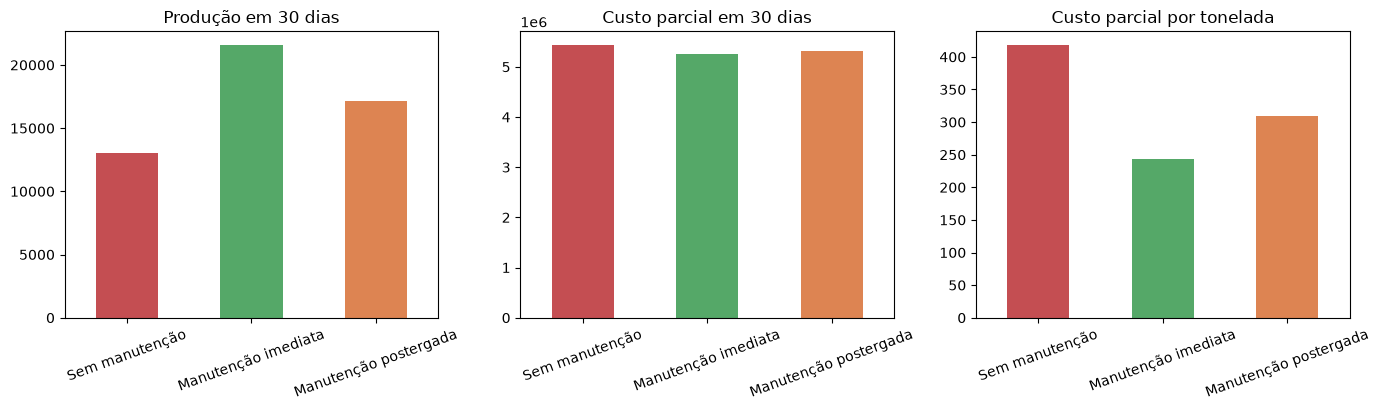

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
colors = ["#C44E52", "#55A868", "#DD8452"]
scenarios["Produção (ton)"].plot.bar(ax=axes[0], color=colors, title="Produção em 30 dias")
scenarios["Custo total parcial (R$)"].plot.bar(ax=axes[1], color=colors, title="Custo parcial em 30 dias")
scenarios["Custo parcial/ton (R$)"].plot.bar(ax=axes[2], color=colors, title="Custo parcial por tonelada")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

### 4.3 Sensibilidade financeira e diagnóstico de extrapolação

In [23]:
def immediate_saving(energy_price=ENERGY_PRICE, maintenance_cost=MAINTENANCE_NOW, failure_cost=FAILURE_COST):
    total_a = ei_a * y_a * HORIZON * energy_price + p_now * failure_cost
    total_b = ei_b * y_b * (HORIZON-DOWNTIME) * energy_price + maintenance_cost + p_restored * failure_cost
    return total_a - total_b

sensitivity = []
for label, param, base in [
    ("Preço da energia", "energy_price", ENERGY_PRICE),
    ("Custo de manutenção", "maintenance_cost", MAINTENANCE_NOW),
    ("Custo de falha", "failure_cost", FAILURE_COST),
]:
    values = [immediate_saving(**{param: base * factor}) for factor in (.7, 1.3)]
    sensitivity.append({"Premissa": label, "Economia mínima": min(values), "Economia máxima": max(values)})
sensitivity_df = pd.DataFrame(sensitivity)
display(sensitivity_df.round(2))

# Isolation Forest mede raridade, não risco. Percentil baixo = estado raro no treino.
iso = IsolationForest(n_estimators=300, random_state=RANDOM_STATE).fit(train_df[risk_features])
historical_scores = iso.score_samples(train_df[risk_features])
def normality_percentile(state):
    row = pd.DataFrame([{k: state[k] for k in risk_features}])
    score = iso.score_samples(row)[0]
    return float((historical_scores <= score).mean() * 100)

pd.Series({
    "Estado degradado — percentil de normalidade": normality_percentile(state_now),
    "Referência saudável — percentil de normalidade": normality_percentile(state_restored),
}).to_frame("percentil")

,Premissa,Economia mínima,Economia máxima
0,Preço da energia,157809.12,192779.16
1,Custo de manutenção,161794.14,188794.14
2,Custo de falha,126690.92,223897.36


,percentil
Estado degradado — percentil de normalidade,0.4375
Referência saudável — percentil de normalidade,20.1125


A referência saudável é uma observação real e bem mais comum que o caso degradado. Mesmo assim, esse teste só mede suporte estatístico. Sem eventos de falha e registros antes/depois de manutenção, não é possível estimar probabilidade real nem provar ganho causal.

## 5. Automação da decisão

| Decisão | Nível recomendado | Regra |
|---|---|---|
| Monitoramento e cálculo dos scores | Automático | Alertar sobre dados ausentes, drift e condição rara |
| Sugestão de setpoints | Automático supervisionado | Aplicar somente dentro dos limites de engenharia e com rollback |
| Parada para manutenção | Recomendação + aprovação humana | Engenharia confirma sensores, segurança, produção e janela de parada |

Benefícios: velocidade, escala, consistência, operação contínua e menor tempo até detectar degradação. Riscos: falso positivo, falso negativo, erro de modelo, sensor incorreto, drift, extrapolação e impacto de parada indevida.

## 6. Pipeline final

```text
Dados → qualidade/EDA → features sem leakage → walk-forward
      → calibração conformal → teste final → diagnóstico de suporte
      → otimização nominal/robusta → cenários → custo/risco
      → recomendação → aprovação humana de manutenção
```

## 7. Resultado final

In [24]:
recommended = opt_maintenance
final_table = pd.DataFrame([{
    "Feedstock Flow (m³/h)": recommended["x"]["Feedstock_Flow_m3h"],
    "Reactor Temperature (°C)": recommended["x"]["Reactor_Temp_C"],
    "Reactor Pressure (bar)": recommended["x"]["Reactor_Pressure_Bar"],
    "Valve Opening (%)": recommended["x"]["Valve_Opening_Percent"],
    "Expected Yield (ton/4h)": recommended["yield"],
    "Energy Intensity": recommended["energy"],
    "Margem conformal EI (90%)": energy_error_q90,
    "Energy Cost 30d (R$)": scenarios.loc["Manutenção imediata", "Custo energia (R$)"],
    "Maintenance": "Sim, condicionada à inspeção humana",
    "Maintenance Cost (R$)": scenarios.loc["Manutenção imediata", "Custo manutenção (R$)"],
    "Total Cost 30d (R$; parcial)": scenarios.loc["Manutenção imediata", "Custo total parcial (R$)"],
    "Nível de automação recomendado": "Setpoints supervisionados; manutenção com aprovação humana",
}]).T
final_table.columns = ["Configuração recomendada"]
final_table

,Configuração recomendada
Feedstock Flow (m³/h),694.105849
Reactor Temperature (°C),795.136349
Reactor Pressure (bar),33.3225
Valve Opening (%),79.534948
Expected Yield (ton/4h),121.247507
Energy Intensity,1.848837
Margem conformal EI (90%),0.552104
Energy Cost 30d (R$),5187222.732799
Maintenance,"Sim, condicionada à inspeção humana"
Maintenance Cost (R$),45000.0


## 8. Conclusão

- **Configuração:** usar os valores da tabela final, após validação pelos limites oficiais de engenharia. A solução permanece próxima de combinações históricas e mantém produção acima da referência observada.
- **Manutenção:** o caso selecionado está entre os estados mais degradados do teste. Recomenda-se inspeção imediata e manutenção caso a degradação seja confirmada. O dataset, sozinho, não autoriza parada automática.
- **Impacto econômico:** sob as premissas didáticas declaradas, a manutenção imediata reduz custo parcial e custo por tonelada. A comparação adicional fixa a produção em 10 mil toneladas e a sensibilidade mostra quanto da conclusão depende da recuperação realmente causada pela intervenção. O valor não é um business case completo.
- **Riscos:** qualidade de sensores, erro do modelo de energia, mudança de processo, extrapolação, premissas financeiras e ausência de rótulos de falha/manutenção.
- **Automação:** monitoramento e sugestão de setpoints podem ser automáticos com guardrails; manutenção exige aprovação humana.
- **Dados necessários para produção:** falhas e ordens de manutenção, estado antes/depois, limites oficiais, preço por fonte de energia, custo e duração de intervenções, valor/margem do produto, estoque, demanda e penalidades de indisponibilidade.